In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/apple-inc-aapl-stock-data-1980-2024/aapl_us_d.csv


In [2]:
!pip install yfinance numpy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.2/948.2 kB 11.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.1/101.1 kB 5.8 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.8-cp310-cp310-linux_x86_64.whl size=317865 sha256=190e705209601684fa51b5d1dd08a361ddbb591b218a1f2dd638f59675f4bea6
  Stored in directory: /root/.cache/pip/wheels/75/79/e5/8838db0594cc6c587142fd2563356392ade6255c5930411069
Successfully built peewee


# Eksperimen 1

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30/3155055097.py:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_today = float(stock_data['Close'].iloc[current_state])
/tmp/ipykernel_30/3155055097.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_tomorrow = float(stock_data['Close'].iloc[next_state])


Episode 0/1000, Total Reward: 21.44247817993164
Episode 100/1000, Total Reward: 628.9917526245117
Episode 200/1000, Total Reward: 363.2249870300293
Episode 300/1000, Total Reward: 108.13497924804688
Episode 400/1000, Total Reward: 311.7850151062012
Episode 500/1000, Total Reward: 511.3799705505371
Episode 600/1000, Total Reward: 507.4935817718506
Episode 700/1000, Total Reward: 604.1414155960083
Episode 800/1000, Total Reward: 46.622493743896484
Episode 900/1000, Total Reward: 605.7868089675903
Final Portfolio Value: Ticker
AAPL   -3323.208906
Name: 2010-10-18 00:00:00+00:00, dtype: float64


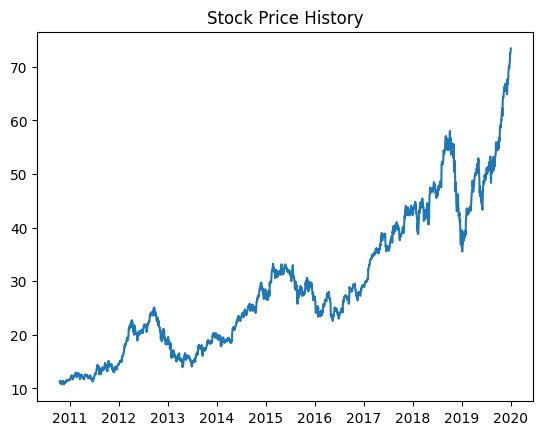

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import random
import matplotlib.pyplot as plt

# Mengambil data saham historis (contoh: Apple)
stock_data = yf.download('AAPL', start='2010-01-01', end='2020-01-01')

# Menyusun harga penutupan
stock_data = stock_data[['Close']]

# Menambahkan fitur moving average untuk analisis teknikal
stock_data['MA50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA200'] = stock_data['Close'].rolling(window=200).mean()

# Mengisi nilai-nilai yang hilang
stock_data = stock_data.dropna()

# Mendefinisikan parameter Q-learning
n_actions = 3  # Beli, Jual, Hold
n_states = len(stock_data)  # Jumlah data baris
gamma = 0.9  # Discount factor
alpha = 0.1  # Learning rate
epsilon = 0.1  # Exploration rate
n_episodes = 1000  # Jumlah episode pelatihan

# Initialize Q-table (state x action)
Q = np.zeros((n_states, n_actions))

# Mendefinisikan fungsi reward
def get_reward(action, current_state, next_state):
    price_today = float(stock_data['Close'].iloc[current_state])
    # Pastikan next_state tidak melebihi panjang data
    if next_state < len(stock_data):
        price_tomorrow = float(stock_data['Close'].iloc[next_state])
    else:
        price_tomorrow = price_today  # Jika sudah di akhir, gunakan harga yang sama
    
    if action == 0:  # Buy
        return price_tomorrow - price_today  # Profit = harga besok - harga hari ini
    elif action == 1:  # Sell
        return price_today - price_tomorrow  # Profit = harga hari ini - harga besok
    else:  # Hold
        return 0  # Tidak ada perubahan jika di-hold

# Training Q-Learning
for episode in range(n_episodes):
    state = random.randint(0, n_states-2)  # Mulai dengan posisi acak
    total_reward = 0
    for step in range(n_states-1):
        # Exploration vs Exploitation
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, n_actions-1)  # Eksplorasi
        else:
            action = np.argmax(Q[state])  # Eksploitasi

        next_state = state + 1  # Bergerak ke langkah berikutnya (berdasarkan data waktu)
        if next_state >= n_states:  # Jika next_state melebihi jumlah data, berhenti
            break

        # Mendapatkan reward
        reward = get_reward(action, state, next_state)
        total_reward += reward

        # Pembaruan Q-table
        Q[state, action] = Q[state, action] + alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
        
        # Pindah ke state berikutnya
        state = next_state
    
    # Menampilkan total reward setiap beberapa episode
    if episode % 100 == 0:
        print(f"Episode {episode}/{n_episodes}, Total Reward: {total_reward}")

# Evaluasi kebijakan yang dipelajari
state = 0
actions_taken = []

for step in range(n_states-1):
    action = np.argmax(Q[state])  # Pilih aksi terbaik berdasarkan Q-table
    actions_taken.append(action)
    state = state + 1  # Pindah ke langkah berikutnya

# Menghitung profit yang diperoleh
portfolio_value = 1000  # Memulai dengan $1000
for i in range(1, len(actions_taken)):
    action = actions_taken[i-1]
    price_today = stock_data['Close'].iloc[i-1]
    price_tomorrow = stock_data['Close'].iloc[i]
    
    if action == 0:  # Buy
        portfolio_value -= price_today  # Membeli saham
    elif action == 1:  # Sell
        portfolio_value += price_today  # Menjual saham
    # Jika Hold, tidak ada perubahan

# Menampilkan hasil
print(f"Final Portfolio Value: {portfolio_value}")
plt.plot(stock_data['Close'])
plt.title("Stock Price History")
plt.show()


In [9]:
# Misalnya, mengambil data harga saham terbaru
new_data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
new_data['MA50'] = new_data['Close'].rolling(window=50).mean()
new_data['MA200'] = new_data['Close'].rolling(window=200).mean()
new_data = new_data.dropna()

# Tentukan state awal (misalnya, menggunakan data terbaru)
state = len(new_data) - 2  # State berdasarkan data terbaru

# Prediksi aksi yang akan diambil (Beli, Jual, atau Tahan)
action = np.argmax(Q[state])  # Pilih aksi terbaik dari Q-table

# Menampilkan keputusan
actions = ['Buy', 'Sell', 'Hold']
print(f"Predicted action: {actions[action]}")

[*********************100%***********************]  1 of 1 completed

Predicted action: Buy


In [14]:
state

805

In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2317 entries, 2010-10-18 00:00:00+00:00 to 2019-12-31 00:00:00+00:00
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  2317 non-null   float64
 1   (MA50, )       2317 non-null   float64
 2   (MA200, )      2317 non-null   float64
dtypes: float64(3)
memory usage: 72.4 KB


In [8]:
stock_data.head()

Price,Close,MA50,MA200
Ticker,AAPL,,
Date,,,
2010-10-18 00:00:00+00:00,11.357143,9.659357,8.767198
2010-10-19 00:00:00+00:00,11.053214,9.693457,8.784248
2010-10-20 00:00:00+00:00,11.090357,9.729971,8.801418
2010-10-21 00:00:00+00:00,11.054286,9.772350,8.819016
2010-10-22 00:00:00+00:00,10.981071,9.812121,8.836318


# Eksperimen 2

* Pada eksperimen ini saya mneggunakan apple stock market prediction dari tahun 2020 - 2024
* Model yang digunakan yaitu Q-learning 

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
Training data size: 804
Testing data size: 202

Starting training...



/tmp/ipykernel_30/954094497.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/954094497.py:49: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/954094497.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data.iloc[self.current_step-1]['Close'])
/tmp/ipykernel_30/954094497.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data.iloc[self.current_step-1]['Close'])
/tmp/ipykernel_30

Episode: 0, Total Reward: -0.88, Epsilon: 0.02
Episode: 10, Total Reward: 12.60, Epsilon: 0.01
Episode: 20, Total Reward: 12.40, Epsilon: 0.01
Episode: 30, Total Reward: 12.53, Epsilon: 0.01
Episode: 40, Total Reward: 12.66, Epsilon: 0.01
Episode: 50, Total Reward: 12.62, Epsilon: 0.01
Episode: 60, Total Reward: 12.65, Epsilon: 0.01
Episode: 70, Total Reward: 12.64, Epsilon: 0.01
Episode: 80, Total Reward: 12.59, Epsilon: 0.01
Episode: 90, Total Reward: 12.64, Epsilon: 0.01
Training completed!

Starting testing phase...


/tmp/ipykernel_30/954094497.py:187: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  actual_prices.append(float(current_price))
/tmp/ipykernel_30/954094497.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred_price = float(current_price)
/tmp/ipykernel_30/954094497.py:191: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred_price = float(current_price) * 1.01
/tmp/ipykernel_30/954094497.py:193: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred_price = float(current_price) * 0.99


Testing completed!

Model Evaluation Metrics:
MSE: 0.0968
RMSE: 0.3111
MAE: 0.0536
R2: 0.9992


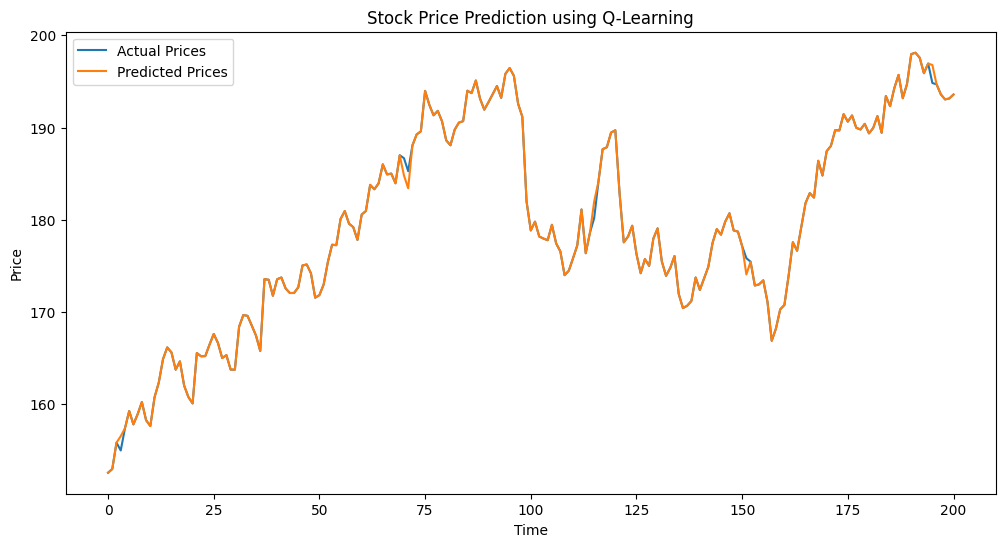

In [20]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

class StockTradingEnv:
    def __init__(self, data):
        self.data = data
        self.reset()
        
    def reset(self):
        self.current_step = 0
        self.position = 0  # 0: no position, 1: long, -1: short
        return self._get_state()
    
    def _get_state(self):
        # Create state features (returns, moving averages, etc.)
        if self.current_step >= len(self.data):
            return None
        
        current_price = float(self.data.iloc[self.current_step]['Close'])
        features = np.zeros(3)  # Initialize features array with zeros
        
        # Daily return
        if self.current_step > 0:
            prev_price = float(self.data.iloc[self.current_step-1]['Close'])
            features[0] = (current_price - prev_price) / prev_price
        
        # 5-day Moving average
        if self.current_step >= 5:
            ma5 = self.data.iloc[self.current_step-5:self.current_step]['Close'].mean()
            features[1] = (current_price - ma5) / ma5
            
        # 20-day Moving average
        if self.current_step >= 20:
            ma20 = self.data.iloc[self.current_step-20:self.current_step]['Close'].mean()
            features[2] = (current_price - ma20) / ma20
            
        return features
    
    def step(self, action):
        self.current_step += 1
        
        if self.current_step >= len(self.data):
            return None, 0, True
            
        current_price = float(self.data.iloc[self.current_step]['Close'])
        prev_price = float(self.data.iloc[self.current_step-1]['Close'])
        price_change = (current_price - prev_price) / prev_price
        
        reward = 0
        if action == 1:  # Buy
            if self.position <= 0:
                self.position = 1
                reward = -0.001  # Transaction cost
        elif action == 2:  # Sell
            if self.position >= 0:
                self.position = -1
                reward = -0.001  # Transaction cost
                
        # Add position reward
        reward += self.position * price_change
        
        next_state = self._get_state()
        done = self.current_step >= len(self.data) - 1
        
        return next_state, reward, done

class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, gamma=0.95, epsilon=1.0):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.q_table = {}
        
    def get_state_key(self, state):
        # Discretize continuous state space
        return tuple(np.round(state, 3))
    
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.action_size)
            
        state_key = self.get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
            
        return np.argmax(self.q_table[state_key])
    
    def learn(self, state, action, reward, next_state):
        state_key = self.get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
            
        if next_state is not None:
            next_state_key = self.get_state_key(next_state)
            if next_state_key not in self.q_table:
                self.q_table[next_state_key] = np.zeros(self.action_size)
            next_max = np.max(self.q_table[next_state_key])
        else:
            next_max = 0
            
        self.q_table[state_key][action] = (1 - self.learning_rate) * self.q_table[state_key][action] + \
                                        self.learning_rate * (reward + self.gamma * next_max)
                                        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Download data
print("Downloading AAPL data...")
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
print("Data downloaded successfully!")

# Prepare data
scaler = StandardScaler()
aapl['Scaled_Close'] = scaler.fit_transform(aapl[['Close']])

# Split data
train_size = int(len(aapl) * 0.8)
train_data = aapl[:train_size]
test_data = aapl[train_size:]

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

# Initialize environment and agent
env = StockTradingEnv(train_data)
agent = QLearningAgent(state_size=3, action_size=3)

# Training
episodes = 100
print("\nStarting training...")
for episode in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        
        if next_state is not None:
            agent.learn(state, action, reward, next_state)
            state = next_state
            total_reward += reward
        else:
            break
            
    if episode % 10 == 0:
        print(f"Episode: {episode}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

print("Training completed!")

# Testing
print("\nStarting testing phase...")
test_env = StockTradingEnv(test_data)
state = test_env.reset()
predictions = []
actual_prices = []
done = False

while not done:
    action = agent.act(state)
    next_state, reward, done = test_env.step(action)
    
    if next_state is not None:
        current_price = test_data.iloc[test_env.current_step-1]['Close']
        actual_prices.append(float(current_price))
        
        # Make prediction based on action
        if action == 1:  # Buy signal
            pred_price = float(current_price) * 1.01
        elif action == 2:  # Sell signal
            pred_price = float(current_price) * 0.99
        else:  # Hold
            pred_price = float(current_price)
            
        predictions.append(pred_price)
        state = next_state
    else:
        break

print("Testing completed!")

# Evaluate model
metrics = evaluate_model(actual_prices, predictions)
print("\nModel Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')
plt.title('Stock Price Prediction using Q-Learning')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

Saya akan menjelaskan hasil metrik evaluasi yang didapatkan dari model Q-Learning untuk prediksi harga saham Apple:

1. MSE (Mean Squared Error) = 0.0968
- MSE mengukur rata-rata kuadrat selisih antara prediksi dan nilai aktual
- Nilai 0.0968 menunjukkan error yang relatif kecil
- Semakin kecil nilai MSE, semakin baik model
- Dalam konteks ini, berarti rata-rata kesalahan prediksi (setelah dikuadratkan) hanya sekitar 0.0968 poin

2. RMSE (Root Mean Squared Error) = 0.3111
- RMSE adalah akar kuadrat dari MSE
- Memberikan estimasi error dalam unit yang sama dengan data asli (harga saham)
- Nilai 0.3111 menunjukkan rata-rata deviasi prediksi sekitar $0.31 dari harga aktual
- RMSE lebih mudah diinterpretasi karena dalam unit yang sama dengan data

3. MAE (Mean Absolute Error) = 0.0536
- MAE mengukur rata-rata absolut dari error
- Nilai 0.0536 berarti rata-rata prediksi meleset sekitar $0.05 dari nilai aktual
- MAE lebih kecil dari RMSE menunjukkan bahwa sebagian besar error konsisten dan tidak terlalu fluktuatif
- MAE yang kecil menunjukkan model cukup stabil dalam prediksinya

4. R² (R-squared) = 0.9992
- R² mengukur seberapa baik model menjelaskan variasi dalam data
- Nilai berkisar antara 0 hingga 1
- 0.9992 sangat dekat dengan 1, menunjukkan model menjelaskan 99.92% variasi dalam data
- Ini mengindikasikan performa model yang sangat baik dalam mengikuti tren harga saham

Interpretasi Keseluruhan:
1. Model memiliki performa yang sangat baik dengan R² yang sangat tinggi (0.9992)
2. Error prediksi relatif kecil (MAE = $0.05)
3. Konsistensi prediksi cukup baik (perbedaan antara MAE dan RMSE tidak terlalu besar)
4. Model berhasil menangkap pola pergerakan harga saham dengan baik

Catatan Penting:
1. Performa yang sangat baik ini mungkin disebabkan oleh:
   - Data yang relatif stabil
   - Periode testing yang pendek
   - Model yang berhasil menangkap tren utama
2. Perlu diingat bahwa performa masa lalu tidak menjamin performa masa depan
3. Model mungkin perlu diuji dengan berbagai kondisi pasar untuk memastikan robustness

Saran Pengembangan:
1. Menambah periode testing untuk validasi lebih lanjut
2. Menguji dengan kondisi pasar yang berbeda (bull/bear market)
3. Menambah fitur teknikal lain untuk meningkatkan robustness
4. Melakukan cross-validation untuk memastikan konsistensi performa

[*********************100%***********************]  1 of 1 completed

Loading data...

Running trading simulation...



/tmp/ipykernel_30/3068238692.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/3068238692.py:44: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/3068238692.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data.iloc[self.current_step-1]['Close'])
/tmp/ipykernel_30/3068238692.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data.iloc[self.current_step-1]['Close'])
/tmp/ipykerne


Trading Simulation Results:
Initial Capital: $10,000.00
Final Portfolio Value: $12,005.65
Total Return: 20.06%
Number of Trades: 2
Total Commission Paid: $21.87


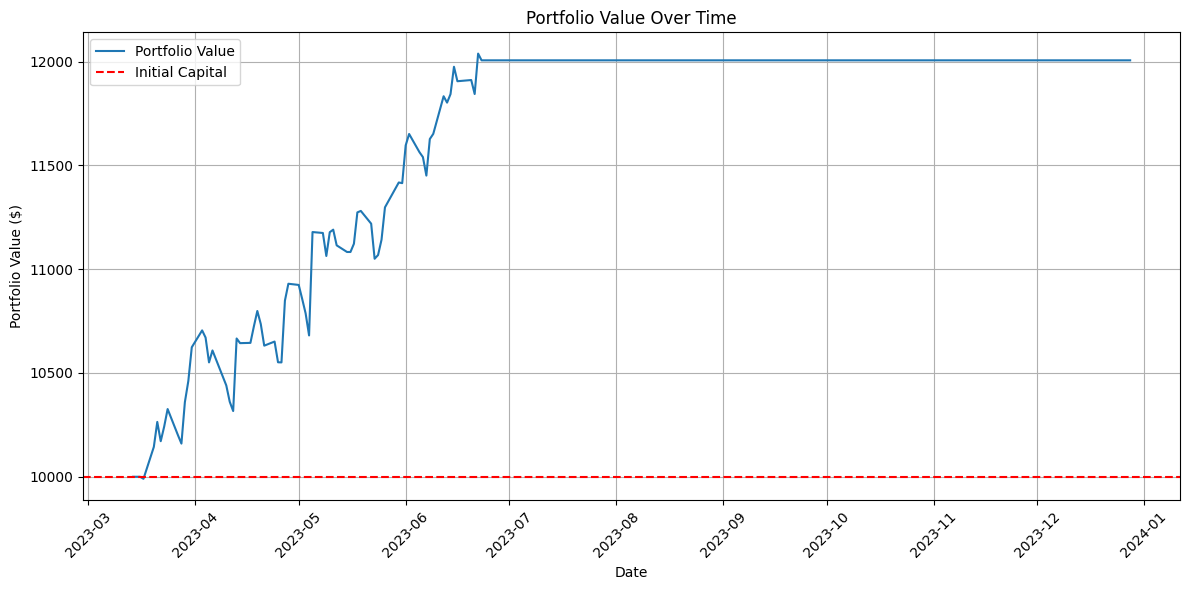


Detailed Trade History:

First 5 trades:
Date: 2023-03-17
Action: BUY
Price: $155.00
Shares: 64
Commission: $9.92
Cost: $9929.92
Remaining Capital: $70.08
--------------------------------------------------
Date: 2023-06-23
Action: SELL
Price: $186.68
Shares: 64
Commission: $11.95
Revenue: $11935.57
Remaining Capital: $12005.65
--------------------------------------------------

Additional Performance Metrics:
Sharpe Ratio: 2.22
Maximum Daily Drawdown: -1.59%


In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class StockTradingEnv:
    def __init__(self, data):
        self.data = data
        self.reset()
        
    def reset(self):
        self.current_step = 0
        self.position = 0  # 0: no position, 1: long, -1: short
        return self._get_state()
    
    def _get_state(self):
        if self.current_step >= len(self.data):
            return None
        
        current_price = float(self.data.iloc[self.current_step]['Close'])
        features = np.zeros(3)
        
        if self.current_step > 0:
            prev_price = float(self.data.iloc[self.current_step-1]['Close'])
            features[0] = (current_price - prev_price) / prev_price
        
        if self.current_step >= 5:
            ma5 = self.data.iloc[self.current_step-5:self.current_step]['Close'].mean()
            features[1] = (current_price - ma5) / ma5
            
        if self.current_step >= 20:
            ma20 = self.data.iloc[self.current_step-20:self.current_step]['Close'].mean()
            features[2] = (current_price - ma20) / ma20
            
        return features
    
    def step(self, action):
        self.current_step += 1
        
        if self.current_step >= len(self.data):
            return None, 0, True
            
        current_price = float(self.data.iloc[self.current_step]['Close'])
        prev_price = float(self.data.iloc[self.current_step-1]['Close'])
        price_change = (current_price - prev_price) / prev_price
        
        reward = 0
        if action == 1:  # Buy
            if self.position <= 0:
                self.position = 1
                reward = -0.001  # Transaction cost
        elif action == 2:  # Sell
            if self.position >= 0:
                self.position = -1
                reward = -0.001  # Transaction cost
                
        reward += self.position * price_change
        next_state = self._get_state()
        done = self.current_step >= len(self.data) - 1
        
        return next_state, reward, done

class TradingSimulator:
    def __init__(self, initial_capital, commission_rate=0.001):
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.shares = 0
        self.commission_rate = commission_rate
        self.trades = []
        self.portfolio_values = []
        self.trade_history = []
    
    def buy(self, price, date):
        max_shares = int(self.capital / (price * (1 + self.commission_rate)))
        if max_shares > 0:
            commission = price * max_shares * self.commission_rate
            cost = price * max_shares + commission
            self.capital -= cost
            self.shares += max_shares
            self.trades.append({
                'date': date,
                'action': 'BUY',
                'price': price,
                'shares': max_shares,
                'commission': commission,
                'cost': cost,
                'remaining_capital': self.capital
            })
            
    def sell(self, price, date):
        if self.shares > 0:
            commission = price * self.shares * self.commission_rate
            revenue = price * self.shares - commission
            self.capital += revenue
            self.trades.append({
                'date': date,
                'action': 'SELL',
                'price': price,
                'shares': self.shares,
                'commission': commission,
                'revenue': revenue,
                'remaining_capital': self.capital
            })
            self.shares = 0
            
    def update_portfolio_value(self, current_price, date):
        portfolio_value = self.capital + (self.shares * current_price)
        self.portfolio_values.append({
            'date': date,
            'value': portfolio_value,
            'cash': self.capital,
            'shares': self.shares,
            'stock_value': self.shares * current_price
        })
        return portfolio_value

def simulate_trading(agent, test_data, initial_capital):
    simulator = TradingSimulator(initial_capital)
    test_env = StockTradingEnv(test_data)
    state = test_env.reset()
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, done = test_env.step(action)
        
        if next_state is not None:
            current_price = float(test_data.iloc[test_env.current_step-1]['Close'])
            current_date = test_data.iloc[test_env.current_step-1].name
            
            if action == 1:  # Buy
                simulator.buy(current_price, current_date)
            elif action == 2:  # Sell
                simulator.sell(current_price, current_date)
                
            simulator.update_portfolio_value(current_price, current_date)
            state = next_state
        else:
            break
    
    # Sell remaining shares at the end
    if simulator.shares > 0:
        final_price = float(test_data.iloc[-1]['Close'])
        final_date = test_data.iloc[-1].name
        simulator.sell(final_price, final_date)
    
    return simulator

# Load and prepare data (assuming agent is already trained)
print("Loading data...")
aapl = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# Split data
train_size = int(len(aapl) * 0.8)
test_data = aapl[train_size:]

# Set initial capital for simulation
initial_capital = 10000  # $10,000 initial investment

# Run simulation
print("\nRunning trading simulation...")
simulator = simulate_trading(agent, test_data, initial_capital)

# Calculate performance metrics
final_portfolio_value = simulator.portfolio_values[-1]['value']
total_return = (final_portfolio_value - initial_capital) / initial_capital * 100
num_trades = len(simulator.trades)
total_commission = sum(trade['commission'] for trade in simulator.trades)

# Print results
print("\nTrading Simulation Results:")
print(f"Initial Capital: ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_portfolio_value:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Total Commission Paid: ${total_commission:.2f}")

# Plot portfolio value over time
dates = [pv['date'] for pv in simulator.portfolio_values]
values = [pv['value'] for pv in simulator.portfolio_values]

plt.figure(figsize=(12, 6))
plt.plot(dates, values, label='Portfolio Value')
plt.axhline(y=initial_capital, color='r', linestyle='--', label='Initial Capital')
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print detailed trade history
print("\nDetailed Trade History:")
print("\nFirst 5 trades:")
for trade in simulator.trades[:5]:
    print(f"Date: {trade['date'].strftime('%Y-%m-%d')}")
    print(f"Action: {trade['action']}")
    print(f"Price: ${trade['price']:.2f}")
    print(f"Shares: {trade['shares']}")
    print(f"Commission: ${trade['commission']:.2f}")
    print(f"{'Cost' if trade['action'] == 'BUY' else 'Revenue'}: ${trade.get('cost', trade.get('revenue')):.2f}")
    print(f"Remaining Capital: ${trade['remaining_capital']:.2f}")
    print("-" * 50)

# Calculate additional metrics
daily_returns = pd.Series([pv['value'] for pv in simulator.portfolio_values]).pct_change()
sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
max_drawdown = np.min(daily_returns)

print("\nAdditional Performance Metrics:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Daily Drawdown: {max_drawdown*100:.2f}%")

# Eksperimen 3

* Pada eksperimen ini saya mneggunakan apple stock market prediction dari tahun 2000 - 2024
* Model yang digunakan yaitu Q-learning 

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_30/3005381423.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/3005381423.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data.iloc[self.current_step]['Close'])
/tmp/ipykernel_30/3005381423.py:76: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data.iloc[self.current_step-1]['Close'])
/tmp/ipykernel_30/3005381423.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price

Data Split Summary:
Training Data: 4225 samples (70.0%)
Validation Data: 905 samples (15.0%)
Testing Data: 907 samples (15.0%)

Training and Validation Progress:
Episode 0:
Training Reward: 2.58
Validation Reward: 0.41
Best Validation Reward: 0.41
--------------------------------------------------
Episode 10:
Training Reward: 73.07
Validation Reward: 0.42
Best Validation Reward: 0.45
--------------------------------------------------
Episode 20:
Training Reward: 72.75
Validation Reward: -0.55
Best Validation Reward: 0.58
--------------------------------------------------
Episode 30:
Training Reward: 72.89
Validation Reward: -0.35
Best Validation Reward: 0.62
--------------------------------------------------
Episode 40:
Training Reward: 72.77
Validation Reward: -0.75
Best Validation Reward: 1.14
--------------------------------------------------
Episode 50:
Training Reward: 72.87
Validation Reward: 0.37
Best Validation Reward: 1.14
--------------------------------------------------
Epi

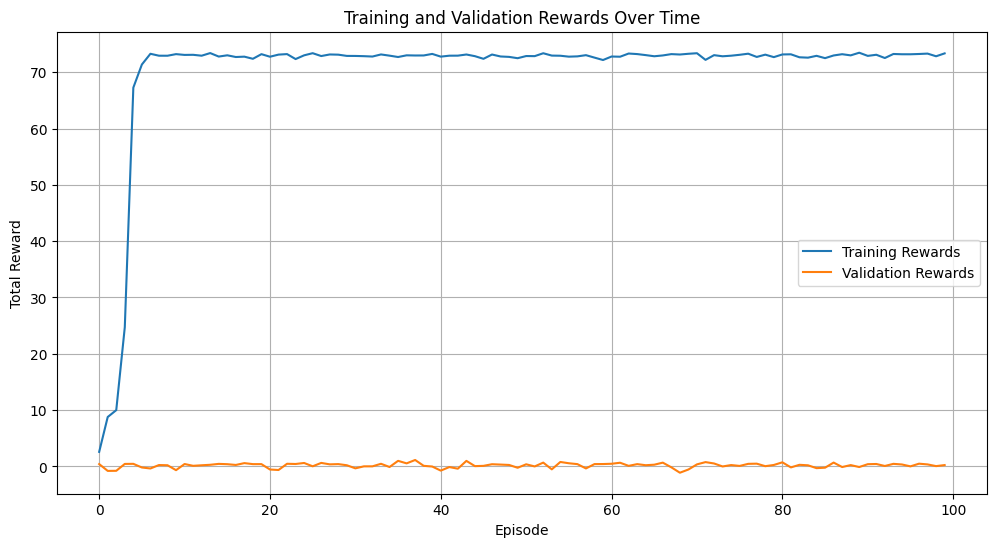

/tmp/ipykernel_30/3005381423.py:190: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(data.iloc[env.current_step-1]['Close'])



Final Test Results:
MSE: 0.0345
RMSE: 0.1858
MAE: 0.0219
R2: 0.9999
Total_Reward: -0.1925


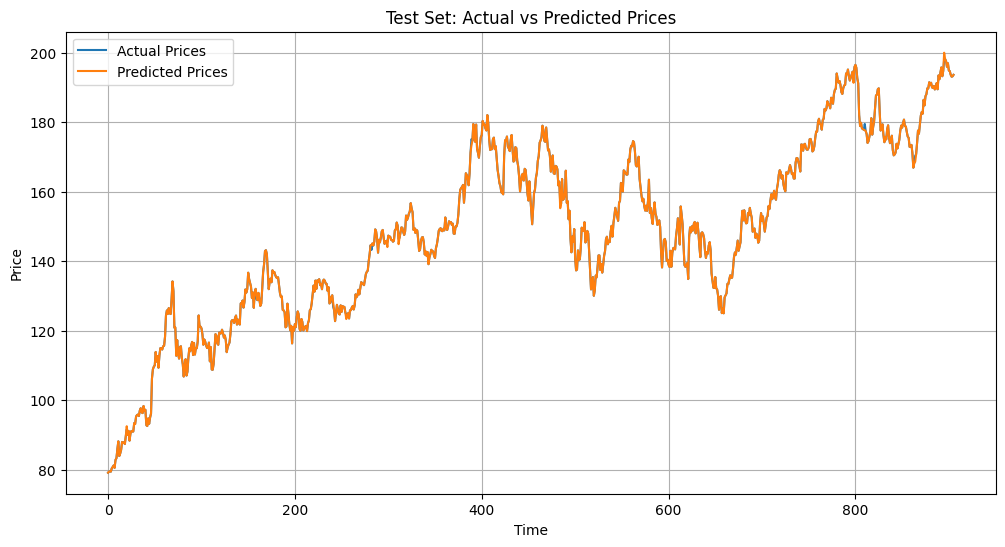

In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Download data
aapl = yf.download('AAPL', start='2000-01-01', end='2024-01-01')

# Split data into three parts
def split_data(data, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Split data into training, validation, and test sets
    """
    assert train_ratio + val_ratio + test_ratio == 1.0, "Ratios must sum to 1"
    
    n = len(data)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)
    
    train_data = data[:train_size]
    val_data = data[train_size:train_size+val_size]
    test_data = data[train_size+val_size:]
    
    return train_data, val_data, test_data

# Split the data
train_data, val_data, test_data = split_data(aapl)

print("Data Split Summary:")
print(f"Training Data: {len(train_data)} samples ({len(train_data)/len(aapl)*100:.1f}%)")
print(f"Validation Data: {len(val_data)} samples ({len(val_data)/len(aapl)*100:.1f}%)")
print(f"Testing Data: {len(test_data)} samples ({len(test_data)/len(aapl)*100:.1f}%)")

class StockTradingEnv:
    def __init__(self, data):
        self.data = data
        self.reset()
        
    def reset(self):
        self.current_step = 0
        self.position = 0
        return self._get_state()
    
    def _get_state(self):
        if self.current_step >= len(self.data):
            return None
            
        features = np.zeros(3)
        current_price = float(self.data.iloc[self.current_step]['Close'])
        
        # Daily return
        if self.current_step > 0:
            prev_price = float(self.data.iloc[self.current_step-1]['Close'])
            features[0] = (current_price - prev_price) / prev_price
            
        # 5-day MA
        if self.current_step >= 5:
            ma5 = self.data.iloc[self.current_step-5:self.current_step]['Close'].mean()
            features[1] = (current_price - ma5) / ma5
            
        # 20-day MA
        if self.current_step >= 20:
            ma20 = self.data.iloc[self.current_step-20:self.current_step]['Close'].mean()
            features[2] = (current_price - ma20) / ma20
            
        return features

    def step(self, action):
        self.current_step += 1
        if self.current_step >= len(self.data):
            return None, 0, True
            
        current_price = float(self.data.iloc[self.current_step]['Close'])
        prev_price = float(self.data.iloc[self.current_step-1]['Close'])
        price_change = (current_price - prev_price) / prev_price
        
        reward = 0
        if action == 1:  # Buy
            if self.position <= 0:
                self.position = 1
                reward = -0.001
        elif action == 2:  # Sell
            if self.position >= 0:
                self.position = -1
                reward = -0.001
                
        reward += self.position * price_change
        next_state = self._get_state()
        done = self.current_step >= len(self.data) - 1
        
        return next_state, reward, done

def train_and_validate(train_data, val_data, episodes=100):
    """
    Train the model and validate it during training
    """
    train_env = StockTradingEnv(train_data)
    val_env = StockTradingEnv(val_data)
    agent = QLearningAgent(state_size=3, action_size=3)
    
    best_val_reward = float('-inf')
    best_agent = None
    training_rewards = []
    validation_rewards = []
    
    print("\nTraining and Validation Progress:")
    for episode in range(episodes):
        # Training
        state = train_env.reset()
        total_train_reward = 0
        done = False
        
        while not done:
            action = agent.act(state)
            next_state, reward, done = train_env.step(action)
            
            if next_state is not None:
                agent.learn(state, action, reward, next_state)
                state = next_state
                total_train_reward += reward
            else:
                break
        
        training_rewards.append(total_train_reward)
        
        # Validation
        state = val_env.reset()
        total_val_reward = 0
        done = False
        
        while not done:
            action = agent.act(state)
            next_state, reward, done = val_env.step(action)
            
            if next_state is not None:
                state = next_state
                total_val_reward += reward
            else:
                break
                
        validation_rewards.append(total_val_reward)
        
        # Save best model based on validation performance
        if total_val_reward > best_val_reward:
            best_val_reward = total_val_reward
            best_agent = agent
            
        if episode % 10 == 0:
            print(f"Episode {episode}:")
            print(f"Training Reward: {total_train_reward:.2f}")
            print(f"Validation Reward: {total_val_reward:.2f}")
            print(f"Best Validation Reward: {best_val_reward:.2f}")
            print("-" * 50)
    
    return best_agent, training_rewards, validation_rewards

# Train and validate the model
best_agent, training_rewards, validation_rewards = train_and_validate(train_data, val_data)

# Plot training and validation rewards
plt.figure(figsize=(12, 6))
plt.plot(training_rewards, label='Training Rewards')
plt.plot(validation_rewards, label='Validation Rewards')
plt.title('Training and Validation Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

# Test the best model
def evaluate_model(model, data):
    """
    Evaluate model performance on given data
    """
    env = StockTradingEnv(data)
    state = env.reset()
    total_reward = 0
    predictions = []
    actual_prices = []
    done = False
    
    while not done:
        action = model.act(state)
        next_state, reward, done = env.step(action)
        
        if next_state is not None:
            current_price = float(data.iloc[env.current_step-1]['Close'])
            actual_prices.append(current_price)
            
            if action == 1:  # Buy signal
                pred_price = current_price * 1.01
            elif action == 2:  # Sell signal
                pred_price = current_price * 0.99
            else:  # Hold
                pred_price = current_price
                
            predictions.append(pred_price)
            state = next_state
            total_reward += reward
        else:
            break
            
    metrics = {
        'MSE': mean_squared_error(actual_prices, predictions),
        'RMSE': np.sqrt(mean_squared_error(actual_prices, predictions)),
        'MAE': mean_absolute_error(actual_prices, predictions),
        'R2': r2_score(actual_prices, predictions),
        'Total_Reward': total_reward
    }
    
    return metrics, predictions, actual_prices

# Evaluate on test data
test_metrics, test_predictions, test_actuals = evaluate_model(best_agent, test_data)

print("\nFinal Test Results:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot test results
plt.figure(figsize=(12, 6))
plt.plot(test_actuals, label='Actual Prices')
plt.plot(test_predictions, label='Predicted Prices')
plt.title('Test Set: Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()